In [4]:
import numpy as np 
import pandas as pd 
import json
# plotting 
import matplotlib.pyplot as plt
# statistical filtering of models
import statsmodels.api as sm
import statsmodels.formula.api as smf
# opening data
import os
import pathlib
import warnings
# used for plots
from scipy import stats
from mplsoccer import PyPizza, FontManager, Pitch

In [5]:
data = r"D:\soccer-data\open-data\data"

# Build Reusable Data Loaders

In [6]:
def load_competition(data):
    file_path = os.path.join(data, "competitions.json")
    with open(file_path) as f:
        competition_data = json.load(f)
    return pd.json_normalize(competition_data)

In [7]:
def load_matches(data, competition_id, season_id):
    file_path = os.path.join(data, 'matches', str(competition_id), f"{season_id}.json") 
    with open(file_path, "r", encoding="utf-8") as f:
        matches_data = json.load(f)
    return pd.json_normalize(matches_data)

In [8]:
def load_events(data, match_id):
    file_path = os.path.join(data, 'events', f"{match_id}.json")
    with open(file_path, "r", encoding="utf-8") as f:
        events_data = json.load(f)
    return pd.json_normalize(events_data)

In [9]:
def load_lineups(data, match_id):
    file_path = os.path.join(data, 'lineups', f"{match_id}.json")
    with open(file_path, "r", encoding="utf-8") as f:
        lineups_data = json.load(f)
    return pd.json_normalize(lineups_data)

In [10]:
def load_three_sixty(data, match_id):
    file_path = os.path.join(data, 'three-sixty', f"{match_id}.json")
    with open(file_path, "r", encoding="utf-8") as f:
        three_sixty_data = json.load(f)
    return pd.json_normalize(three_sixty_data)

# Explore the Data

In [11]:
competitions = load_competition(data)
competitions.head()

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-11-15T23:17:41.827093,2025-11-15T23:17:41.827093,2024-09-28T20:46:38.893391
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,None,None,2024-05-19T11:11:14.192381
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2026-05-12T21:18:08.827431,2026-05-02T02:07:18.902396,2026-05-02T02:07:18.902396,2026-05-12T21:18:08.827431
3,16,4,Europe,Champions League,male,False,False,2018/2019,2026-05-15T15:54:04.598614,2021-06-13T16:17:31.694,None,2026-05-15T15:54:04.598614
4,16,1,Europe,Champions League,male,False,False,2017/2018,2024-02-13T02:35:28.134882,2021-06-13T16:17:31.694,None,2024-02-13T02:35:28.134882


In [12]:
competitions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   competition_id             80 non-null     int64 
 1   season_id                  80 non-null     int64 
 2   country_name               80 non-null     object
 3   competition_name           80 non-null     object
 4   competition_gender         80 non-null     object
 5   competition_youth          80 non-null     bool  
 6   competition_international  80 non-null     bool  
 7   season_name                80 non-null     object
 8   match_updated              80 non-null     object
 9   match_updated_360          58 non-null     object
 10  match_available_360        12 non-null     object
 11  match_available            80 non-null     object
dtypes: bool(2), int64(2), object(8)
memory usage: 6.5+ KB


In [13]:
competitions.describe(include = 'all')

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
count,80.000000,80.000000,80,80,80,80,80,80,80,58,12,80
unique,NaN,NaN,13,24,2,2,2,48,80,15,12,80
top,NaN,NaN,Europe,Champions League,male,False,False,2015/2016,2024-09-28T20:46:38.893391,2021-06-13T16:17:31.694,2025-11-15T23:17:41.827093,2024-09-28T20:46:38.893391
freq,NaN,NaN,23,18,67,79,63,6,1,44,1,1
mean,84.587500,99.825000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,250.356995,103.636875,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,2.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,11.000000,26.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,16.000000,44.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,49.000000,108.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
print(competitions[competitions['season_name'] == '2020'])

    competition_id  season_id country_name competition_name  \
74              55         43       Europe        UEFA Euro   

   competition_gender  competition_youth  competition_international  \
74               male              False                       True   

   season_name               match_updated           match_updated_360  \
74        2020  2026-05-10T12:59:26.302088  2026-05-10T13:00:25.564993   

           match_available_360             match_available  
74  2026-05-10T13:00:25.564993  2026-05-10T12:59:26.302088  


In [15]:
competitions[[
    'competition_id',
    'competition_name',
    'season_id',
    'season_name',
    'country_name'  
]].sort_values(["competition_name", "season_name"])

,competition_id,competition_name,season_id,season_name,country_name
1,9,1. Bundesliga,27,2015/2016,Germany
0,9,1. Bundesliga,281,2023/2024,Germany
2,1267,African Cup of Nations,107,2023,Africa
20,16,Champions League,276,1970/1971,Europe
19,16,Champions League,71,1971/1972,Europe
...,...,...,...,...,...
75,35,UEFA Europa League,75,1988/1989,Europe
77,53,UEFA Women's Euro,106,2022,Europe
76,53,UEFA Women's Euro,315,2025,Europe
79,72,Women's World Cup,30,2019,International


In [16]:
competitions[competitions['competition_name'] == 'FIFA World Cup']

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
30,43,106,International,FIFA World Cup,male,False,True,2022,2026-05-04T01:48:57.914346,2026-05-04T01:53:40.309717,2026-05-04T01:53:40.309717,2026-05-04T01:48:57.914346
31,43,3,International,FIFA World Cup,male,False,True,2018,2026-05-15T15:48:12.789440,2021-06-13T16:17:31.694,None,2026-05-15T15:48:12.789440
32,43,55,International,FIFA World Cup,male,False,True,1990,2023-06-28T10:58:20.137929,2021-06-12T16:17:31.694,None,2023-06-28T10:58:20.137929
33,43,54,International,FIFA World Cup,male,False,True,1986,2026-05-04T01:30:23.212111,2021-06-13T16:17:31.694,None,2026-05-04T01:30:23.212111
34,43,51,International,FIFA World Cup,male,False,True,1974,2026-05-15T02:20:43.439689,2021-06-13T16:17:31.694,None,2026-05-15T02:20:43.439689
35,43,272,International,FIFA World Cup,male,False,True,1970,2026-05-04T02:09:10.916859,None,None,2026-05-04T02:09:10.916859
36,43,270,International,FIFA World Cup,male,False,True,1962,2026-05-04T02:05:35.653887,None,None,2026-05-04T02:05:35.653887
37,43,269,International,FIFA World Cup,male,False,True,1958,2026-05-04T02:02:41.853159,None,None,2026-05-04T02:02:41.853159


In [17]:
matches = load_matches(data, 43, 106)

In [18]:
matches.sort_values('match_date')

,match_id,match_date,kick_off,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,...,competition_stage.id,competition_stage.name,stadium.id,stadium.name,stadium.country.id,stadium.country.name,referee.id,referee.name,referee.country.id,referee.country.name
55,3857286,2022-11-20,16:00:00.000,0,2,available,available,2026-05-03T16:05:33.394676,2026-05-03T16:08:18.843212,1,...,10,Group Stage,1001113,Al Bayt Stadium,185,Qatar,269.0,Daniele Orsato,112.0,Italy
1,3857271,2022-11-21,13:00:00.000,6,2,available,available,2026-05-04T01:40:47.671394,2026-05-04T01:43:30.216315,1,...,10,Group Stage,1000253,Sheikh Khalifa International Stadium,185,Qatar,2638.0,Raphael Claus,31.0,Brazil
14,3857282,2022-11-21,19:00:00.000,1,1,available,available,2026-05-03T16:06:35.237994,2026-05-03T16:07:47.017684,1,...,10,Group Stage,1000793,Ahmad bin Ali Stadium,185,Qatar,2521.0,Abdulrahman Ibrahim Al Jassim,185.0,Qatar
13,3857285,2022-11-21,16:00:00.000,0,2,available,available,2026-05-03T16:07:28.656580,2026-05-03T16:13:03.612730,1,...,10,Group Stage,1000838,Al Thumama Stadium,185,Qatar,986.0,Wilton Pereira Sampaio,31.0,Brazil
19,3857254,2022-11-22,13:00:00.000,0,0,available,available,2026-05-04T01:41:55.231447,2026-05-04T01:42:32.134965,1,...,10,Group Stage,94425,Education City Stadium,185,Qatar,740.0,César Arturo Ramos Palazuelos,147.0,Mexico
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43,3869354,2022-12-10,21:00:00.000,1,2,available,available,2023-03-21T07:09:52.867230,2023-04-26T22:57:33.780657,5,...,11,Quarter-finals,1001113,Al Bayt Stadium,185,Qatar,986.0,Wilton Pereira Sampaio,31.0,Brazil
42,3869519,2022-12-13,21:00:00.000,3,0,available,available,2023-04-19T06:53:52.197711,2023-04-26T22:32:37.808359,6,...,15,Semi-finals,1001114,Lusail Stadium,185,Qatar,269.0,Daniele Orsato,112.0,Italy
44,3869552,2022-12-14,21:00:00.000,2,0,available,available,2024-02-06T16:36:46.784457,2024-02-06T16:45:42.775801,6,...,15,Semi-finals,1001113,Al Bayt Stadium,185,Qatar,740.0,César Arturo Ramos Palazuelos,147.0,Mexico
28,3869684,2022-12-17,17:00:00.000,2,1,available,available,2024-02-13T13:43:25.154307,2024-02-13T13:44:03.865296,7,...,25,3rd Place Final,1000253,Sheikh Khalifa International Stadium,185,Qatar,2521.0,Abdulrahman Ibrahim Al Jassim,185.0,Qatar


In [19]:
print(f"Total matches: {len(matches)}")

Total matches: 64


In [20]:
matches["competition_stage.name"].value_counts()

competition_stage.name
Group Stage        48
Round of 16         8
Quarter-finals      4
Semi-finals         2
3rd Place Final     1
Final               1
Name: count, dtype: int64

In [21]:
print(matches["home_team.home_team_name"].nunique())
print(matches["away_team.away_team_name"].nunique())

32
32


In [22]:
match_id = 3869685
events = load_events(data, match_id)

In [23]:
print('events shape: ', events.shape)

events shape:  (4407, 121)


In [24]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4407 entries, 0 to 4406
Columns: 121 entries, id to bad_behaviour.card.name
dtypes: float64(34), int64(9), object(78)
memory usage: 4.1+ MB


In [25]:
events.head()

,id,index,period,timestamp,minute,second,possession,duration,type.id,type.name,...,ball_recovery.offensive,shot.one_on_one,pass.outswinging,shot.aerial_won,foul_committed.advantage,foul_won.advantage,block.offensive,foul_committed.offensive,bad_behaviour.card.id,bad_behaviour.card.name
0,0584ee21-e3dd-4d9f-95a0-5b5e84be25c3,1,1,00:00:00.000,0,0,1,0.000000,35,Starting XI,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,b32679f8-942e-4122-96a2-015caf75e628,2,1,00:00:00.000,0,0,1,0.000000,35,Starting XI,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,954f6855-de22-46a2-8d09-6fe94eec2b9b,3,1,00:00:00.000,0,0,1,0.000000,18,Half Start,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,6404a8e8-afaf-489d-b65e-173a237ffed5,4,1,00:00:00.000,0,0,1,0.000000,18,Half Start,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,f651a6c4-55e3-4e0f-a178-59414ba83d6a,5,1,00:00:00.578,0,0,2,0.975702,30,Pass,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
events.columns.tolist()

['id',
 'index',
 'period',
 'timestamp',
 'minute',
 'second',
 'possession',
 'duration',
 'type.id',
 'type.name',
 'possession_team.id',
 'possession_team.name',
 'play_pattern.id',
 'play_pattern.name',
 'team.id',
 'team.name',
 'tactics.formation',
 'tactics.lineup',
 'related_events',
 'location',
 'player.id',
 'player.name',
 'position.id',
 'position.name',
 'pass.recipient.id',
 'pass.recipient.name',
 'pass.length',
 'pass.angle',
 'pass.height.id',
 'pass.height.name',
 'pass.end_location',
 'pass.type.id',
 'pass.type.name',
 'pass.body_part.id',
 'pass.body_part.name',
 'carry.end_location',
 'pass.switch',
 'pass.outcome.id',
 'pass.outcome.name',
 'ball_receipt.outcome.id',
 'ball_receipt.outcome.name',
 'under_pressure',
 'off_camera',
 'counterpress',
 'block.deflection',
 'pass.deflected',
 'foul_won.defensive',
 'out',
 'pass.cross',
 'clearance.head',
 'clearance.body_part.id',
 'clearance.body_part.name',
 'pass.through_ball',
 'pass.technique.id',
 'pass.techni

In [27]:
events["type.name"].value_counts()

type.name
Pass               1263
Ball Receipt*      1114
Carry               940
Pressure            361
Ball Recovery       115
Duel                 98
Dribble              54
Block                50
Foul Committed       48
Clearance            45
Foul Won             44
Goal Keeper          44
Shot                 38
Miscontrol           35
Dispossessed         34
Dribbled Past        31
Interception         28
Substitution         13
Half Start           10
Half End             10
Injury Stoppage       9
50/50                 8
Tactical Shift        7
Starting XI           2
Bad Behaviour         2
Player Off            1
Offside               1
Player On             1
Shield                1
Name: count, dtype: int64

In [28]:
events["type.name"].value_counts()

type.name
Pass               1263
Ball Receipt*      1114
Carry               940
Pressure            361
Ball Recovery       115
Duel                 98
Dribble              54
Block                50
Foul Committed       48
Clearance            45
Foul Won             44
Goal Keeper          44
Shot                 38
Miscontrol           35
Dispossessed         34
Dribbled Past        31
Interception         28
Substitution         13
Half Start           10
Half End             10
Injury Stoppage       9
50/50                 8
Tactical Shift        7
Starting XI           2
Bad Behaviour         2
Player Off            1
Offside               1
Player On             1
Shield                1
Name: count, dtype: int64

In [29]:
passes = events[events["type.name"] == "Pass"]

passes.head()

,id,index,period,timestamp,minute,second,possession,duration,type.id,type.name,...,ball_recovery.offensive,shot.one_on_one,pass.outswinging,shot.aerial_won,foul_committed.advantage,foul_won.advantage,block.offensive,foul_committed.offensive,bad_behaviour.card.id,bad_behaviour.card.name
4,f651a6c4-55e3-4e0f-a178-59414ba83d6a,5,1,00:00:00.578,0,0,2,0.975702,30,Pass,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,a5956ecc-d637-44d2-8705-e2079e12013e,8,1,00:00:02.724,0,2,2,4.179173,30,Pass,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,5ba6dfab-49f0-4225-bbb6-8b1e27bc729a,10,1,00:00:16.423,0,16,3,1.123351,30,Pass,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,27829865-a43c-4c50-b545-b09e8a965e16,16,1,00:00:31.843,0,31,4,1.660349,30,Pass,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18,59420b0c-94cc-4fb8-86fb-e1105936f6eb,19,1,00:00:34.727,0,34,4,1.814283,30,Pass,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
passes = events[events["type.name"] == "Pass"].copy()

passes["Completed"] = passes["pass.outcome.name"].isna()

In [31]:
passes[
    [
        "player.name",
        "team.name",
        "location",
        "pass.end_location",
        "pass.length",
        "pass.angle",
        "pass.outcome.name",
        "Completed",
    ]
].head(10)

,player.name,team.name,location,pass.end_location,pass.length,pass.angle,pass.outcome.name,Completed
4,Antoine Griezmann,France,"[61.0, 40.1]","[48.0, 43.2]",13.364505,2.907503,NaN,True
7,Aurélien Djani Tchouaméni,France,"[49.7, 43.6]","[96.0, 1.8]",62.377320,-0.734364,Out,False
9,Nahuel Molina Lucero,Argentina,"[22.7, 80.0]","[36.0, 75.2]",14.139661,-0.346354,NaN,True
15,Rodrigo Javier De Paul,Argentina,"[41.1, 73.9]","[23.2, 62.8]",21.062288,-2.586516,NaN,True
18,Cristian Gabriel Romero,Argentina,"[24.7, 59.4]","[21.5, 32.2]",27.387589,-1.687905,NaN,True
21,Nicolás Hernán Otamendi,Argentina,"[24.0, 27.1]","[21.7, 49.3]",22.318827,1.674032,NaN,True
24,Cristian Gabriel Romero,Argentina,"[22.1, 49.8]","[24.0, 27.3]",22.580080,-1.486552,NaN,True
27,Nicolás Hernán Otamendi,Argentina,"[21.7, 24.5]","[26.6, 3.1]",21.953815,-1.345705,NaN,True
31,Nicolás Alejandro Tagliafico,Argentina,"[29.2, 2.5]","[45.6, 4.2]",16.487875,0.103290,NaN,True
37,Nicolás Alejandro Tagliafico,Argentina,"[44.1, 3.8]","[20.8, 11.9]",24.667793,2.807022,NaN,True


In [32]:
events['x'] = events['location'].apply(
    lambda loc: loc[0] if isinstance(loc, list) else np.nan
)

In [33]:
events['y'] = events['location'].apply(
    lambda loc: loc[1] if isinstance(loc, list) else np.nan
)

In [34]:
events[['type.name', 'location', 'x', 'y']]

,type.name,location,x,y
0,Starting XI,NaN,NaN,NaN
1,Starting XI,NaN,NaN,NaN
2,Half Start,NaN,NaN,NaN
3,Half Start,NaN,NaN,NaN
4,Pass,"[61.0, 40.1]",61.0,40.1
...,...,...,...,...
4402,Goal Keeper,"[1.0, 40.0]",1.0,40.0
4403,Shot,"[108.1, 40.1]",108.1,40.1
4404,Goal Keeper,"[1.0, 40.0]",1.0,40.0
4405,Half End,NaN,NaN,NaN


In [35]:
events["type.name"].value_counts()

type.name
Pass               1263
Ball Receipt*      1114
Carry               940
Pressure            361
Ball Recovery       115
Duel                 98
Dribble              54
Block                50
Foul Committed       48
Clearance            45
Foul Won             44
Goal Keeper          44
Shot                 38
Miscontrol           35
Dispossessed         34
Dribbled Past        31
Interception         28
Substitution         13
Half Start           10
Half End             10
Injury Stoppage       9
50/50                 8
Tactical Shift        7
Starting XI           2
Bad Behaviour         2
Player Off            1
Offside               1
Player On             1
Shield                1
Name: count, dtype: int64

In [36]:
events.groupby("type.name")["location"].apply(lambda x: x.isna().sum())

type.name
50/50               0
Bad Behaviour       2
Ball Receipt*       0
Ball Recovery       0
Block               0
Carry               0
Clearance           0
Dispossessed        0
Dribble             0
Dribbled Past       0
Duel                0
Foul Committed      0
Foul Won            0
Goal Keeper         0
Half End           10
Half Start         10
Injury Stoppage     9
Interception        0
Miscontrol          0
Offside             0
Pass                0
Player Off          1
Player On           1
Pressure            0
Shield              0
Shot                0
Starting XI         2
Substitution       13
Tactical Shift      7
Name: location, dtype: int64

In [37]:
events['end_x'] = events['pass.end_location'].apply(
    lambda loc: loc[0] if isinstance(loc, list) else np.nan
)

In [38]:
events['end_y'] = events['pass.end_location'].apply(
    lambda loc: loc[1] if isinstance(loc, list) else np.nan
)

In [39]:
events[
    [
        "type.name",
        "location",
        "pass.end_location",
        "x",
        "y",
        "end_x",
        "end_y"
    ]
].head(10)

,type.name,location,pass.end_location,x,y,end_x,end_y
0,Starting XI,NaN,NaN,NaN,NaN,NaN,NaN
1,Starting XI,NaN,NaN,NaN,NaN,NaN,NaN
2,Half Start,NaN,NaN,NaN,NaN,NaN,NaN
3,Half Start,NaN,NaN,NaN,NaN,NaN,NaN
4,Pass,"[61.0, 40.1]","[48.0, 43.2]",61.0,40.1,48.0,43.2
5,Ball Receipt*,"[48.0, 43.2]",NaN,48.0,43.2,NaN,NaN
6,Carry,"[48.0, 43.2]",NaN,48.0,43.2,NaN,NaN
7,Pass,"[49.7, 43.6]","[96.0, 1.8]",49.7,43.6,96.0,1.8
8,Ball Receipt*,"[92.7, 11.7]",NaN,92.7,11.7,NaN,NaN
9,Pass,"[22.7, 80.0]","[36.0, 75.2]",22.7,80.0,36.0,75.2


In [40]:
passes = passes.rename(
    columns={
        "pass.length": "pass_length",
        "pass.angle": "pass_angle"
    }
)

In [41]:
passes = events[events["type.name"] == "Pass"].copy()

passes["pass_completed"] = passes["pass.outcome.name"].isna()

In [42]:
shots = events[events['type.name'] == 'Shot'].copy()

In [43]:
print('Total shots: ', len(shots))

Total shots:  38


In [44]:
shots[
    [
        "player.name",
        "team.name",
        "minute",
        "location",
        "shot.outcome.name",
        "shot.body_part.name",
        "shot.technique.name",
        "shot.statsbomb_xg"
    ]
].head(15)

,player.name,team.name,minute,location,shot.outcome.name,shot.body_part.name,shot.technique.name,shot.statsbomb_xg
191,Alexis Mac Allister,Argentina,4,"[92.4, 30.0]",Saved,Right Foot,Normal,0.024542
339,Rodrigo Javier De Paul,Argentina,7,"[99.2, 47.9]",Blocked,Right Foot,Normal,0.062813
601,Ángel Fabián Di María Hernández,Argentina,16,"[103.1, 34.6]",Off T,Right Foot,Normal,0.106801
770,Lionel Andrés Messi Cuccittini,Argentina,22,"[108.0, 40.0]",Goal,Left Foot,Normal,0.783500
978,Alexis Mac Allister,Argentina,31,"[94.3, 23.5]",Wayward,Right Foot,Half Volley,0.010578
1177,Ángel Fabián Di María Hernández,Argentina,35,"[111.8, 32.1]",Goal,Left Foot,Normal,0.303409
1915,Rodrigo Javier De Paul,Argentina,48,"[103.3, 52.3]",Saved,Right Foot,Volley,0.040216
2203,Julián Álvarez,Argentina,58,"[110.5, 24.9]",Saved,Left Foot,Normal,0.059534
2234,Lionel Andrés Messi Cuccittini,Argentina,59,"[109.7, 46.0]",Off T,Right Foot,Normal,0.115560
2516,Randal Kolo Muani,France,67,"[113.4, 34.6]",Off T,Head,Normal,0.096184


In [45]:
shots[
    [
        "player.name",
        "x",
        "y"
    ]
].head()

,player.name,x,y
191,Alexis Mac Allister,92.4,30.0
339,Rodrigo Javier De Paul,99.2,47.9
601,Ángel Fabián Di María Hernández,103.1,34.6
770,Lionel Andrés Messi Cuccittini,108.0,40.0
978,Alexis Mac Allister,94.3,23.5


## Shot Map


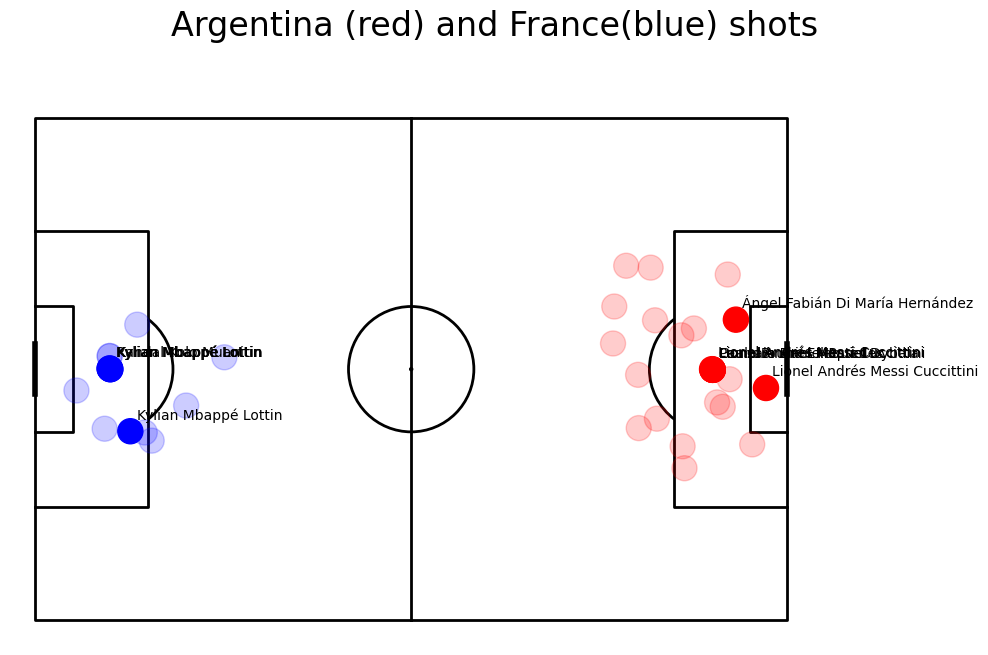

In [46]:
pitch = Pitch(line_color='black')
fig, ax = pitch.draw(figsize=(10, 7))
pitchLengthX = 120
pitchWidthY = 80

for i, shot in shots.iterrows():
    x=shot['x']
    y=shot['y']
    goal=shot['shot.outcome.name']=='Goal'
    team_name=shot['team.name']
    
    circleSize = 2
    if(team_name=='Argentina'):
        if goal:
            shotCircle=plt.Circle((x,y),circleSize,color='red')
            plt.text(x+1, y-2,shot['player.name'])
        else:
            shotCircle=plt.Circle((x,y),circleSize,color='red')
            shotCircle.set_alpha(.2)
    else:
        if goal:
            shotCircle=plt.Circle((pitchLengthX - x,pitchWidthY - y),circleSize,color='blue')
            plt.text(pitchLengthX - x+1, pitchWidthY - y-2, shot['player.name'])
        else:
            shotCircle=plt.Circle((pitchLengthX-x, pitchWidthY - y-2), circleSize, color='blue')
            shotCircle.set_alpha(.2)
    ax.add_patch(shotCircle)
    
fig.suptitle('Argentina (red) and France(blue) shots', fontsize = 24)  
fig.set_size_inches(10,7)
plt.show()      

## Messi Pass Map

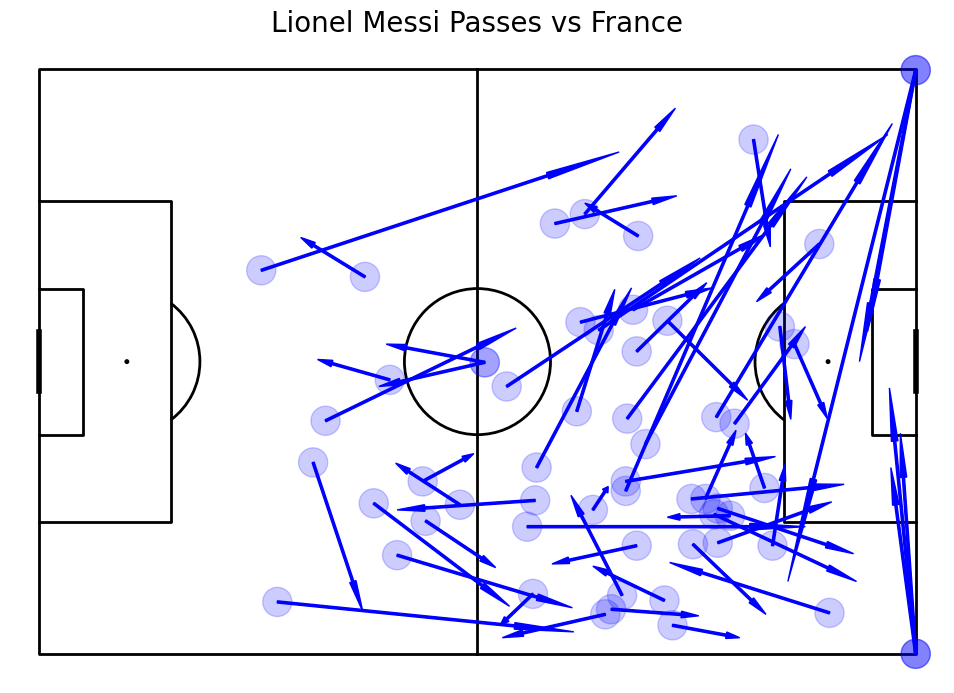

In [47]:
pitch = Pitch(line_color='black')
fig, ax = pitch.draw(figsize=(10,7))

for _, thepass in passes.iterrows():

    if thepass["player.name"] == "Lionel Andrés Messi Cuccittini":

        x = thepass["x"]
        y = thepass["y"]

        passCircle = plt.Circle(
            (x, y),
            2,
            color="blue",
            alpha=0.2
        )

        ax.add_patch(passCircle)

        dx = thepass["end_x"] - x
        dy = thepass["end_y"] - y

        passArrow = plt.Arrow(
            x,
            y,
            dx,
            dy,
            width=1.5,
            color="blue"
        )

        ax.add_patch(passArrow)

ax.set_title("Lionel Messi Passes vs France", fontsize=20)

plt.show()

## Passing Network

In [48]:
team_name = "Argentina"
print(events[events['team.name'] == team_name]["player.name"].value_counts())

player.name
Enzo Fernandez                     328
Lionel Andrés Messi Cuccittini     242
Rodrigo Javier De Paul             242
Nicolás Hernán Otamendi            215
Cristian Gabriel Romero            203
Alexis Mac Allister                196
Nicolás Alejandro Tagliafico       165
Julián Álvarez                     150
Nahuel Molina Lucero               142
Ángel Fabián Di María Hernández    132
Marcos Javier Acuña                112
Damián Emiliano Martínez            83
Gonzalo Ariel Montiel               55
Leandro Daniel Paredes              45
Lautaro Javier Martínez             34
Paulo Bruno Exequiel Dybala         11
Germán Alejandro Pezzella            3
Name: count, dtype: int64


In [49]:
arg_player_names_map = {
    'Nahuel Molina Lucero': 'Molina',
    'Cristian Gabriel Romero': 'Romero',
    'Nicolás Hernán Otamendi': 'Otamendi',
    'Enzo Fernandez': 'Enzo',
    'Lionel Andrés Messi Cuccittini': 'Messi',
    'Gonzalo Ariel Montiel': 'Montiel',
    'Marcos Javier Acuña': 'Acuña',
    'Leandro Daniel Paredes': 'Paredes',
    'Damián Emiliano Martínez': 'Emiliano Martinez',
    'Alexis Mac Allister': 'Mac Allister',
    'Nicolás Alejandro Tagliafico': 'Tagliafico',
    'Julián Álvarez': 'Álvarez',
    'Ángel Fabián Di María Hernández': 'Di María',
    'Lautaro Javier Martínez': 'Lautaro Martínez',
    'Paulo Bruno Exequiel Dybala': 'Dybala',
    'Germán Alejandro Pezzella': 'Pezzella',
    'Rodrigo Javier De Paul': 'De Paul'
}

In [50]:
team_name = 'Argentina'

sub = events.loc[events['type.name'] == 'Substitution'].loc[events['team.name'] == team_name].iloc[0]['index']
mask = (events['type.name'] == 'Pass') & (events['team.name'] == team_name) & (events['index'] < sub) & (events['pass.outcome.name'].isna() & (events['play_pattern.name'] != 'From Throw In'))
events_passes = events.loc[mask, ['x', 'y', 'end_x', 'end_y', 'player.name', 'pass.recipient.name']].copy()
events_passes["arg_player"] = events_passes["player.name"].map(arg_player_names_map)
events_passes["arg_recepient"] = events_passes["pass.recipient.name"].map(arg_player_names_map)

In [51]:
scatter_df = pd.DataFrame()
for i, name in enumerate(events_passes['arg_player'].unique()):
    passx = events_passes.loc[events_passes['arg_player'] == name]['x'].to_numpy()
    recx = events_passes.loc[events_passes['arg_recepient'] == name]['end_x'].to_numpy()
    passy = events_passes.loc[events_passes['arg_player'] == name]['y'].to_numpy()
    recy = events_passes.loc[events_passes['arg_recepient'] == name]['end_y'].to_numpy()
    scatter_df.at[i, "arg_player"] = name
    scatter_df.at[i, "x"] = np.mean(np.concatenate([passx, recx]))
    scatter_df.at[i, "y"] = np.mean(np.concatenate([passy, recy]))

    scatter_df.at[i, "no"] = events_passes.loc[events_passes["arg_player"] == name].count().iloc[0]

scatter_df['marker_size'] = (scatter_df['no'] / scatter_df['no'].max())* 2500+300

In [52]:
events_passes['pair_key'] = events_passes.apply(lambda x: '_'.join(sorted([x['arg_player'], x['arg_recepient']])), axis = 1)
lines_df = events_passes.groupby(['pair_key']).x.count().reset_index()
lines_df.rename({'x':'pass_count'}, axis = 'columns', inplace=True)

lines_df = lines_df[lines_df['pass_count'] >= 5]

<function matplotlib.pyplot.show(close=None, block=None)>

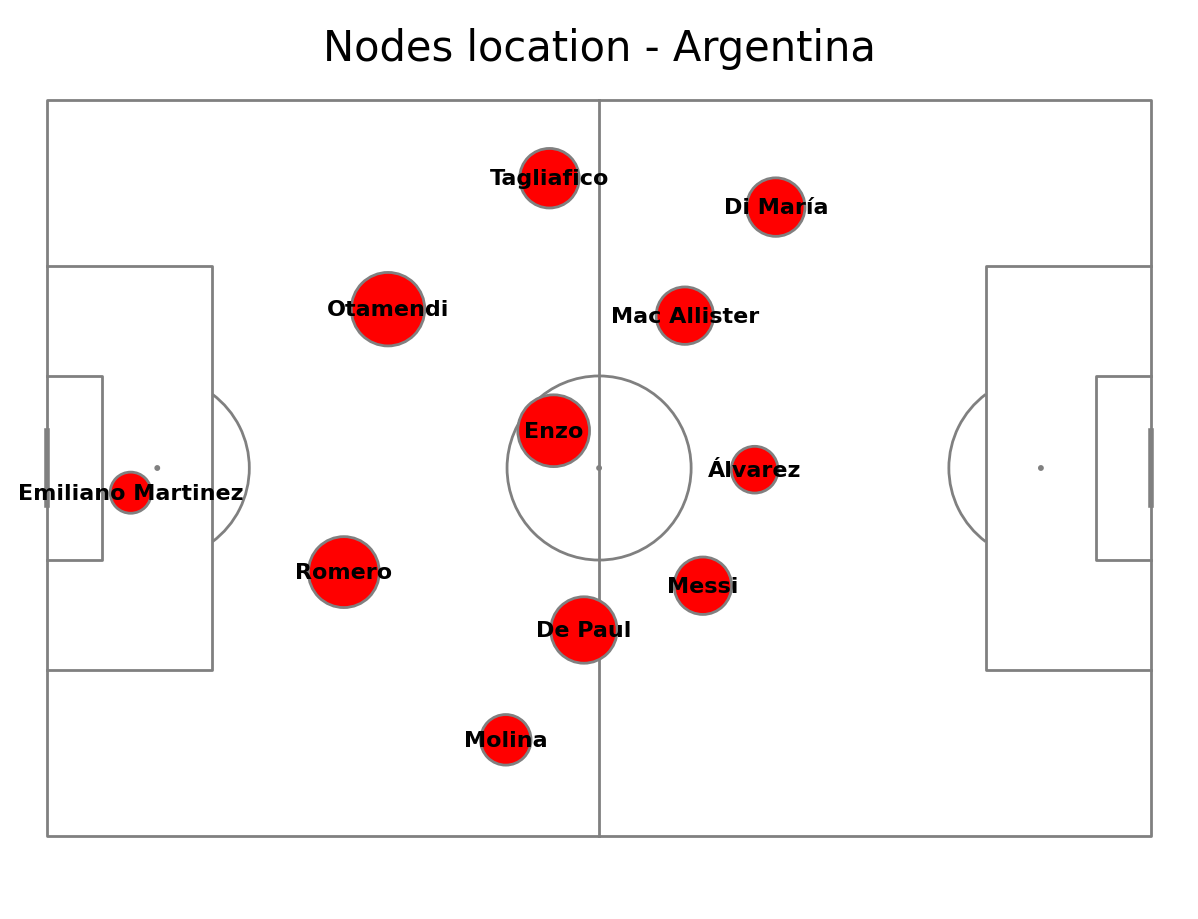

In [53]:
pitch = Pitch(line_color='grey')
fig, ax = pitch.grid(grid_height=0.9, title_height=0.06, axis=False,
                     endnote_height=0.04, title_space=0, endnote_space=0)
pitch.scatter(scatter_df.x, scatter_df.y, s=scatter_df.marker_size, color='red', edgecolors='grey', linewidth=2, ax=ax['pitch'], zorder = 3)
for i, row in scatter_df.iterrows():
    pitch.annotate(row.arg_player, xy=(row.x, row.y), c='black', va='center', ha='center', weight = 'bold', size=16, ax=ax['pitch'], zorder=4)

fig.suptitle("Nodes location - Argentina", fontsize = 30)
plt.show

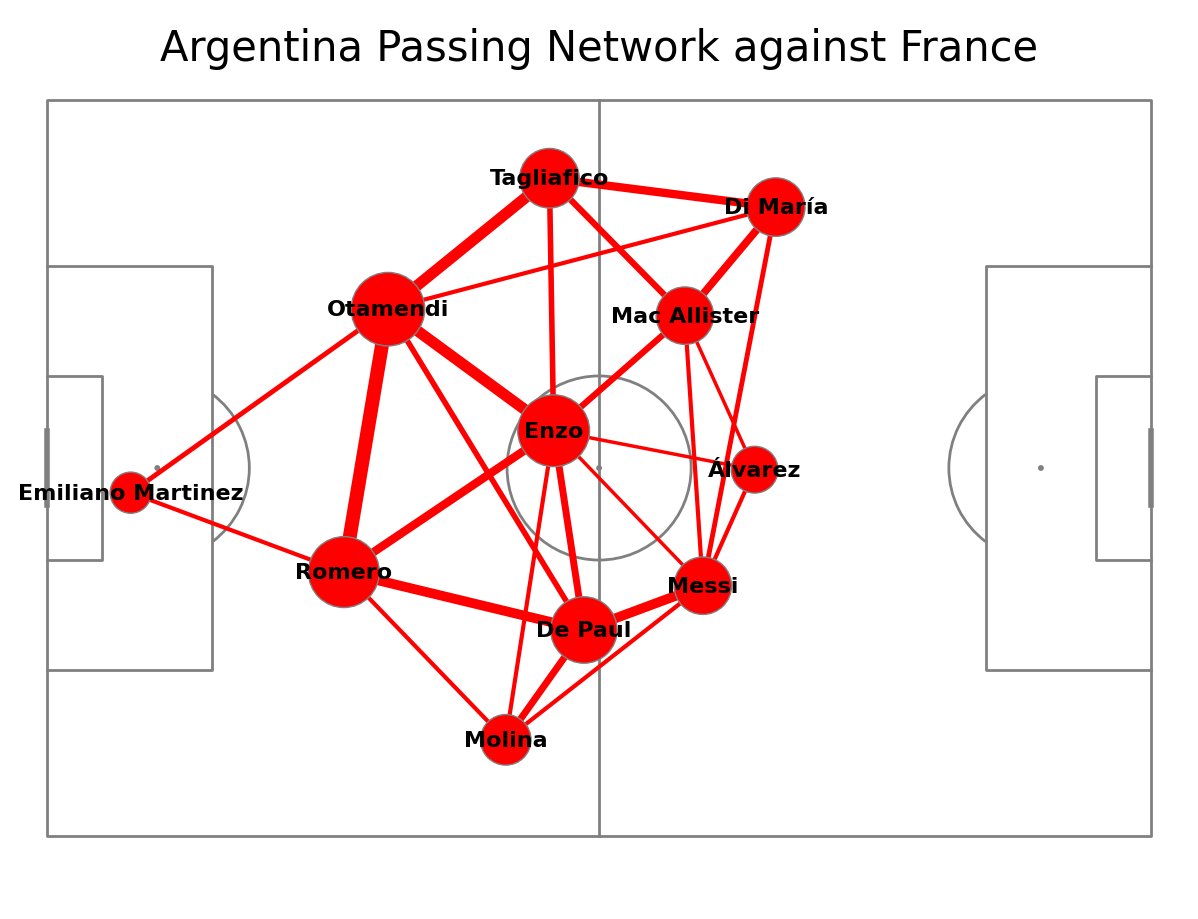

In [54]:
pitch = Pitch(line_color='grey')
fig, ax = pitch.grid(grid_height=0.9, title_height=0.06, axis=False, endnote_height=0.04, title_space=0, endnote_space = 0)
pitch.scatter(scatter_df.x, scatter_df.y, s=scatter_df.marker_size, color='red', edgecolors='grey', linewidth=1, alpha=1, ax=ax['pitch'], zorder = 3)
for i, row in scatter_df.iterrows():
    pitch.annotate(row.arg_player, xy=(row.x, row.y), c='black', va='center', ha='center', weight = "bold", size=16, ax=ax["pitch"], zorder = 4)
for  i, row in lines_df.iterrows():
    player1 = row['pair_key'].split('_')[0]
    player2 = row['pair_key'].split('_')[1]
    
    player1_x = scatter_df.loc[scatter_df['arg_player'] == player1]['x'].iloc[0]
    player1_y = scatter_df.loc[scatter_df['arg_player'] == player1]['y'].iloc[0]
    player2_x = scatter_df.loc[scatter_df["arg_player"] == player2]['x'].iloc[0]
    player2_y = scatter_df.loc[scatter_df["arg_player"] == player2]['y'].iloc[0]
    num_passes = row['pass_count']
    
    line_width = (num_passes / lines_df['pass_count'].max() * 10)
    pitch.lines(player1_x, player1_y, player2_x, player2_y, alpha=1, lw=line_width, zorder=2, color='red', ax = ax['pitch'])
    
fig.suptitle('Argentina Passing Network against France', fontsize = 30)
plt.show()


## Distribution of Xg in Argentina Vs. France WC Final


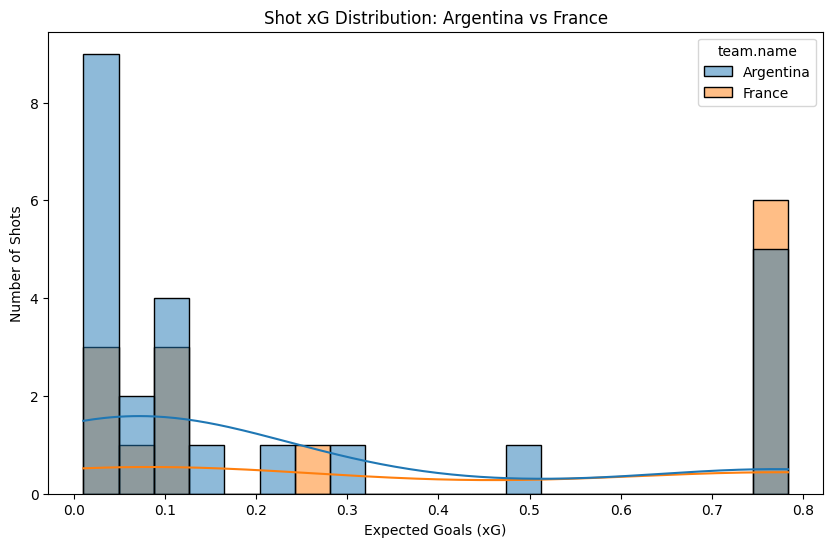

In [82]:
fig, ax = plt.subplots(figsize=(10,6))

sns.histplot(
    data=shots,
    x="shot.statsbomb_xg",
    hue="team.name",
    bins=20,
    kde=True,
    stat="count",
    alpha=0.5,
    ax=ax
)

ax.set_xlabel("Expected Goals (xG)")
ax.set_ylabel("Number of Shots")
ax.set_title("Shot xG Distribution: Argentina vs France")

plt.show()

### The penalties influence the Xg, the next step is separating the penalties

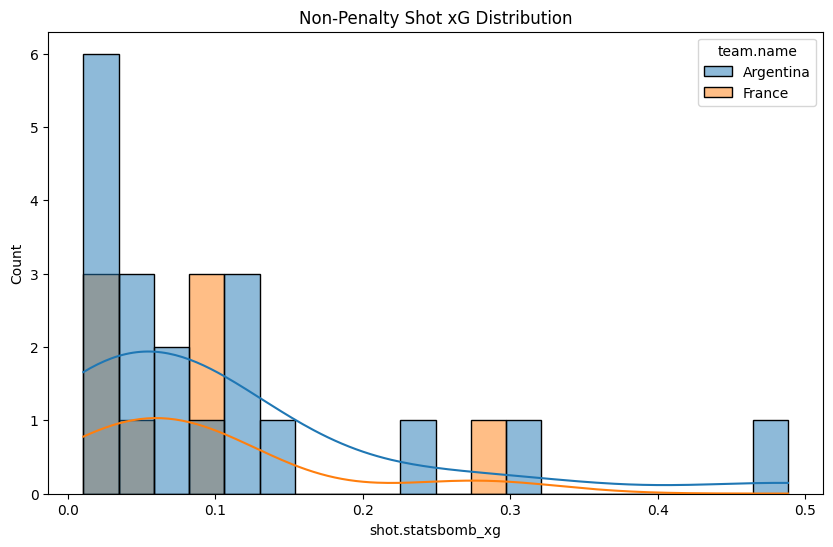

In [83]:
non_penalty = shots[shots["shot.type.name"] != "Penalty"]

fig, ax = plt.subplots(figsize=(10,6))

sns.histplot(
    data=non_penalty,
    x="shot.statsbomb_xg",
    hue="team.name",
    bins=20,
    kde=True,
    alpha=0.5,
    ax=ax
)

ax.set_title("Non-Penalty Shot xG Distribution")
plt.show()

In [84]:
shots.groupby("team.name")["shot.statsbomb_xg"].agg(
    ["count", "sum", "mean", "median", "max"]
)

,count,sum,mean,median,max
team.name,,,,,
Argentina,24,5.892306,0.245513,0.105311,0.7835
France,14,5.406618,0.386187,0.189608,0.7835
